/var/folders/k0/q2ncgz050jd3c9d6y1qks52c0000gn/T/ipykernel_34319/3528164844.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(single_model_runs, ignore_index=True)


Successfully generated and saved comparison matrix to: cache_policies_comparative_summary.png


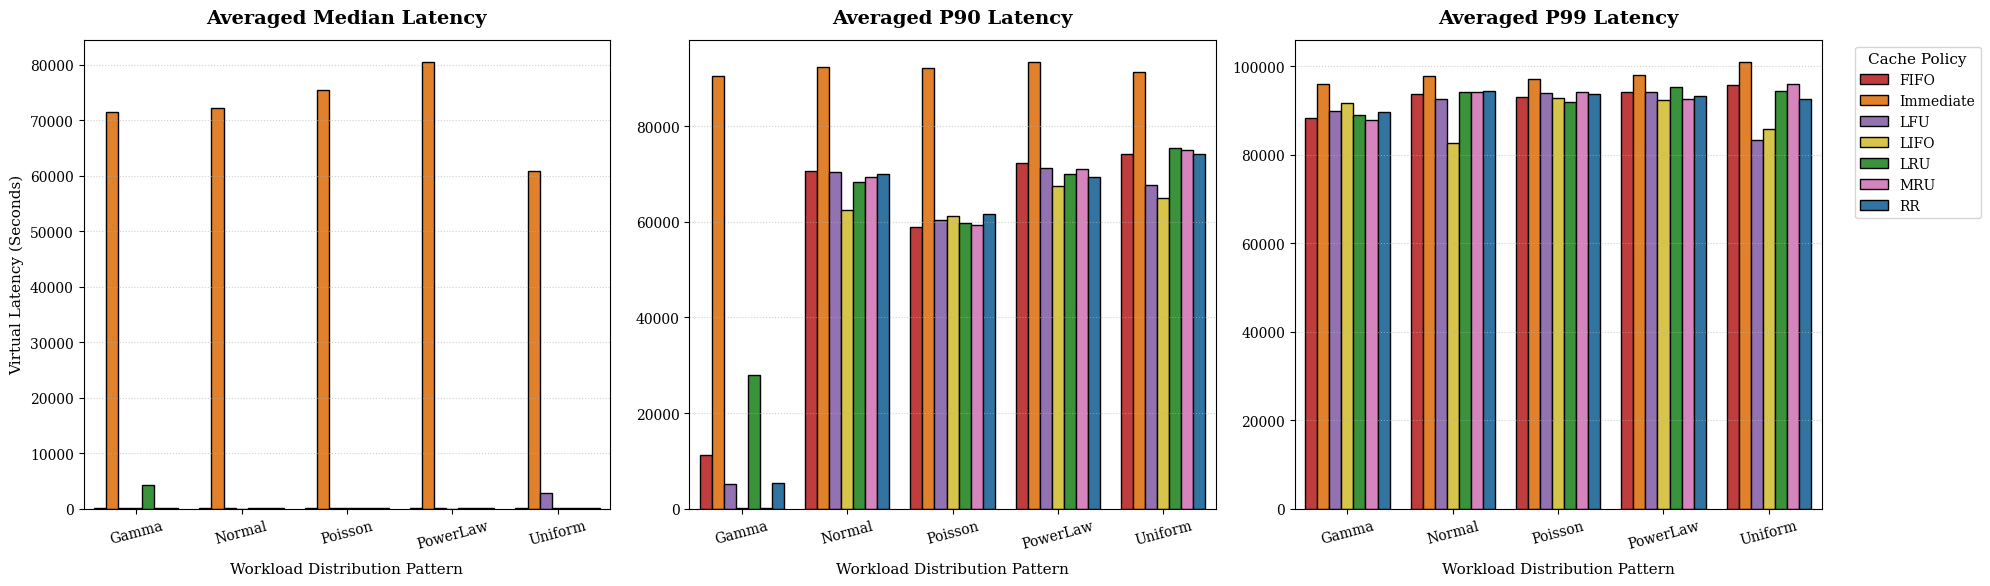

In [12]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Reuse your exact color scheme for report consistency
POLICY_COLORS = {
    'LRU': '#2ca02c',
    'RR': '#1f77b4',
    'Immediate': '#ff7f0e',
    'LFU': '#9467bd',
    'FIFO': '#d62728',
    'LIFO': '#edd534',
    'MRU': '#e377c2',
    'LFRU': '#7f7f7f'
}

def load_and_average_results(pattern="../res/real_life/bench_*.csv"):
    single_model_runs = []
    files = glob.glob(pattern)
    
    for f in files:
        base = os.path.basename(f).replace('.csv', '')
        parts = base.split('_')
        if len(parts) < 6 or parts[0] != 'bench' or parts[3] != 'Single':
            continue
            
        policy, dist_type = parts[1], parts[2]
        num_clients = int(parts[4].replace('c', ''))
        iteration = int(parts[5].replace('iter', ''))

        df = pd.read_csv(f)
        req_df = df.groupby('RequestID')['Duration_Sec'].sum().reset_index()
        req_df['Policy'] = policy
        req_df['Distribution'] = dist_type
        req_df['Clients'] = num_clients
        req_df['Iteration'] = iteration
        single_model_runs.append(req_df)

    if not single_model_runs:
        print("No matching single-model data files found.")
        return pd.DataFrame()

    combined_df = pd.concat(single_model_runs, ignore_index=True)
    
    # Calculate quantiles per iteration
    iter_quantiles = combined_df.groupby(['Policy', 'Distribution', 'Clients', 'Iteration'])['Duration_Sec'].agg(
        Median='median',
        P90=lambda x: x.quantile(0.90),
        P99=lambda x: x.quantile(0.99)
    ).reset_index()
    
    # Average quantiles across all 10 iterations
    averaged_df = iter_quantiles.groupby(['Policy', 'Distribution', 'Clients'])[['Median', 'P90', 'P99']].mean().reset_index()
    averaged_df.columns = ['Policy', 'Distribution', 'Clients', 'Median Latency', 'P90 Latency', 'P99 Latency']
    return averaged_df

def plot_combined_metrics(df_avg):
    if df_avg.empty:
        return
        
    # Transform data from wide to long format for clean seaborn faceting
    df_melted = pd.melt(
        df_avg, 
        id_vars=['Policy', 'Distribution', 'Clients'], 
        value_vars=['Median Latency', 'P90 Latency', 'P99 Latency'],
        var_name='Metric', 
        value_name='Latency_Sec'
    )

    # Setup a 1-row, 3-column subplots figure structure to prevent overlapping text
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
    metrics = ['Median Latency', 'P90 Latency', 'P99 Latency']
    
    # Define a clean alphabetical sorting for the policies to lock bar order
    policy_order = sorted(df_avg['Policy'].unique())

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        metric_data = df_melted[df_melted['Metric'] == metric]
        
        sns.barplot(
            data=metric_data, 
            x='Distribution', 
            y='Latency_Sec', 
            hue='Policy', 
            hue_order=policy_order,
            palette=POLICY_COLORS, 
            edgecolor='black',
            linewidth=1,
            ax=ax
        )
        
        # Style configuration for clean academic aesthetics
        ax.set_title(f"Averaged {metric}", fontsize=14, fontweight='bold', pad=12)
        ax.set_xlabel("Workload Distribution Pattern", fontsize=11, labelpad=8)
        ax.set_ylabel("Virtual Latency (Seconds)" if idx == 0 else "", fontsize=11)
        ax.grid(axis='y', linestyle=':', alpha=0.6)
        ax.tick_params(axis='x', rotation=15) # Subtle tilt to prevent label truncation
        
        # Consolidate legends into a single master legend on the far right subplot
        if idx != len(metrics) - 1:
            ax.get_legend().remove()
        else:
            ax.legend(title='Cache Policy', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

    plt.tight_layout()
    
    # Save directly as a high-resolution file for your LaTeX document
    output_path = "cache_policies_comparative_summary.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Successfully generated and saved comparison matrix to: {output_path}")

# --- Execution Flow ---
df_single_avg = load_and_average_results()
plot_combined_metrics(df_single_avg)

In [13]:
df_single_avg

,Policy,Distribution,Clients,Median Latency,P90 Latency,P99 Latency
0,FIFO,Gamma,10,35.352693,11139.642652,88290.169211
1,FIFO,Normal,10,39.907117,70761.816237,93697.521063
2,FIFO,Poisson,10,38.278700,58921.216711,93038.187749
3,FIFO,PowerLaw,10,37.072847,72406.931387,94248.201381
4,FIFO,Uniform,10,42.574959,74135.113888,95791.795689
5,Immediate,Gamma,10,71486.604459,90450.987688,96002.831424
6,Immediate,Normal,10,72205.890103,92513.000062,97898.672688
7,Immediate,Poisson,10,75499.776592,92209.489983,97075.498499
8,Immediate,PowerLaw,10,80520.077557,93474.005200,97940.886036
9,Immediate,Uniform,10,60845.910084,91338.810510,100958.629243


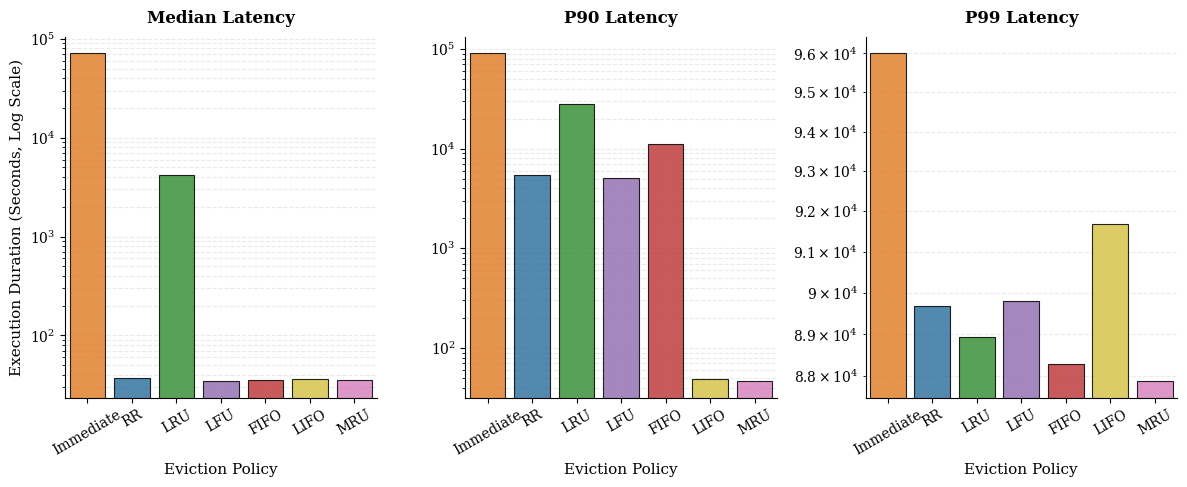

In [14]:
df = df_single_avg[(df_single_avg['Distribution'] == 'Gamma')]
df_melted = pd.melt(
    df, 
    id_vars=['Policy', 'Distribution'], 
    value_vars=['Median Latency', 'P90 Latency', 'P99 Latency'],
    var_name='Metric', 
    value_name='Latency_Sec'
)

# 3. Apply institutional styling defaults (ACM / IEEE Transaction style basics)
plt.rcParams.update({
    'font.family': 'serif',       # Use professional serif typeface (matches LaTeX body text)
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14
})

# Define your strict policy order to ensure consistent presentation across charts
policy_order = ["Immediate", "RR", "LRU", "LFU", "FIFO", "LIFO", "MRU"]

# Reuse your exact color mapping dictionary to maintain coherence across your thesis figures
POLICY_COLORS = {
    'LRU': '#2ca02c', 'RR': '#1f77b4', 'Immediate': '#ff7f0e', 'LFU': '#9467bd',
    'FIFO': '#d62728', 'LIFO': '#edd534', 'MRU': '#e377c2'
}

# 4. Construct the FacetGrid
# We share the x-axis, but set sharey=False so each metric can scale its axis naturally
g = sns.FacetGrid(
    df_melted, 
    col="Metric", 
    col_order=['Median Latency', 'P90 Latency', 'P99 Latency'],
    sharey=False, 
    sharex=True,
    height=5, 
    aspect=0.8
)

# 5. Map the bar plot onto the grid matrix
g.map_dataframe(
    sns.barplot, 
    x='Policy', 
    y='Latency_Sec', 
    hue='Policy',
    order=policy_order,
    hue_order=policy_order,
    palette=POLICY_COLORS,
    edgecolor='black',
    linewidth=0.8,
    alpha=0.85
)

# 6. Polishing axes, grid structures, and text labels
# 6. Polishing axes, grid structures, and text labels
for ax in g.axes.flat:
    current_title = ax.get_title().split('=')[-1].strip()
    ax.set_title(current_title, fontweight='bold', pad=10)
    
    # CRITICAL CHANGE: Switch the vertical axis to log scale
    ax.set_yscale('log')
    
    # Configure clean gridlines that look good on a log scale
    ax.grid(axis='y', which='both', linestyle='--', alpha=0.4, color='#cccccc')
    ax.set_axisbelow(True)
    
    ax.set_xlabel("Eviction Policy")
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("Execution Duration (Seconds, Log Scale)")
    else:
        ax.set_ylabel("")
        
    ax.tick_params(axis='x', rotation=30)

# Adjust spacing properties to fit tightly within standard margins
plt.tight_layout()

# Save as vector graphics (.pdf) or high-resolution raster (.png) for clean print inclusion
output_img = "gamma_distribution_metrics_comparison.pdf"
plt.savefig(output_img, bbox_inches='tight', dpi=300)
plt.show()

In [19]:
# 1. Enforce your explicit academic custom ordering
desired_policies = ["Immediate", "RR", "LRU", "LFU", "FIFO", "LIFO", "MRU"]
# desired_dists = ["Uniform", "Normal", "PowerLaw", "Poisson", "Gamma"]
desired_dists = ["Gamma", "PowerLaw", "Poisson"]  # Adjust this list based on your actual distributions in the DataFrame

# Filter out only the policies and distributions that exist in your current DataFrame slice
policies = [p for p in desired_policies if p in df_single_avg['Policy'].unique()]
distributions = [d for d in desired_dists if d in df_single_avg['Distribution'].unique()]

# 2. Build the LaTeX table string
latex_str = "% \\usepackage{booktabs} -- Mandatory for clean professional horizontal lines\n"
latex_str += "% \\usepackage{multirow} -- Mandatory for multirow alignment\n"
latex_str += "\\begin{table*}[htbp]\n"
latex_str += "\\centering\n"
latex_str += "\\caption{Cache Eviction Policy Performance Matrix across Workload Distributions (Seconds)}\n"
latex_str += "\\label{tab:policy_perf_matrix}\n"

# Setup column alignments: 1 left-aligned for metrics/policies, and right-aligned for each distribution
col_alignment = "ll" + "r" * len(distributions)
latex_str += f"\\begin{{tabular}}{{{col_alignment}}}\n"
latex_str += "\\toprule\n"

# Table Header Row - Now follows your exact distribution sequence
headers = ["Policy", "Metric"] + distributions
latex_str += " & ".join(headers) + " \\\\\n"
latex_str += "\\midrule\n"

# Populate the Matrix using the strict order arrays
for policy in policies:
    # Handle specific renaming for LaTeX presentation if your dataframe uses abbreviations
    display_policy = "Random (RR)" if policy == "RR" else policy
    
    med_row = f"\\multirow{{3}}{{*}}{{\\textbf{{{display_policy}}}}}" + " & Median"
    p90_row = " & P90"
    p99_row = " & P99"
    
    for dist in distributions:
        # Filter for the intersection cell matching current row/col
        subset = df_single_avg[(df_single_avg['Policy'] == policy) & (df_single_avg['Distribution'] == dist)]
        
        if not subset.empty:
            row_data = subset.iloc[0]
            # Look up values dynamically based on what your dataframe columns are named
            med_col = 'Median Latency' if 'Median Latency' in row_data else 'Avg_Median_Sec'
            p90_col = 'P90 Latency' if 'P90 Latency' in row_data else 'Avg_P90_Sec'
            p99_col = 'P99 Latency' if 'P99 Latency' in row_data else 'Avg_P99_Sec'
            
            med_val = f"{row_data[med_col]:.3f}"
            p90_val = f"{row_data[p90_col]:.3f}"
            p99_val = f"{row_data[p99_col]:.3f}"
        else:
            # Fallback if a specific permutation run is missing or skipped
            med_val = p90_val = p99_val = "N/A"
            
        med_row += f" & {med_val}"
        p90_row += f" & {p90_val}"
        p99_row += f" & {p99_val}"
        
    latex_str += med_row + " \\\\\n"
    latex_str += p90_row + " \\\\\n"
    latex_str += p99_row + " \\\\\n"
    latex_str += "\\cmidrule(lr){1-1} \\cmidrule(lr){2-2} " + " ".join([f"\\cmidrule(lr){{{i+3}-{i+3}}}" for i in range(len(distributions))]) + "\n"

# Strip the trailing midrule safely and seal the table structure
latex_str = latex_str.rsplit('\\cmidrule', 1)[0] + "\\bottomrule\n\\end{tabular}\n\\end{table*}"

print(latex_str)

% \usepackage{booktabs} -- Mandatory for clean professional horizontal lines
% \usepackage{multirow} -- Mandatory for multirow alignment
\begin{table*}[htbp]
\centering
\caption{Cache Eviction Policy Performance Matrix across Workload Distributions (Seconds)}
\label{tab:policy_perf_matrix}
\begin{tabular}{llrrr}
\toprule
Policy & Metric & Gamma & PowerLaw & Poisson \\
\midrule
\multirow{3}{*}{\textbf{Immediate}} & Median & 71486.604 & 80520.078 & 75499.777 \\
 & P90 & 90450.988 & 93474.005 & 92209.490 \\
 & P99 & 96002.831 & 97940.886 & 97075.498 \\
\cmidrule(lr){1-1} \cmidrule(lr){2-2} \cmidrule(lr){3-3} \cmidrule(lr){4-4} \cmidrule(lr){5-5}
\multirow{3}{*}{\textbf{Random (RR)}} & Median & 36.706 & 38.057 & 37.997 \\
 & P90 & 5438.482 & 69391.012 & 61588.365 \\
 & P99 & 89685.935 & 93376.725 & 93634.384 \\
\cmidrule(lr){1-1} \cmidrule(lr){2-2} \cmidrule(lr){3-3} \cmidrule(lr){4-4} \cmidrule(lr){5-5}
\multirow{3}{*}{\textbf{LRU}} & Median & 4194.429 & 37.450 & 37.077 \\
 & P90 & 28007.

/var/folders/k0/q2ncgz050jd3c9d6y1qks52c0000gn/T/ipykernel_34319/3811979229.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(single_model_runs, ignore_index=True)


Successfully generated and saved comparison matrix to: cache_policies_comparative_summary.png


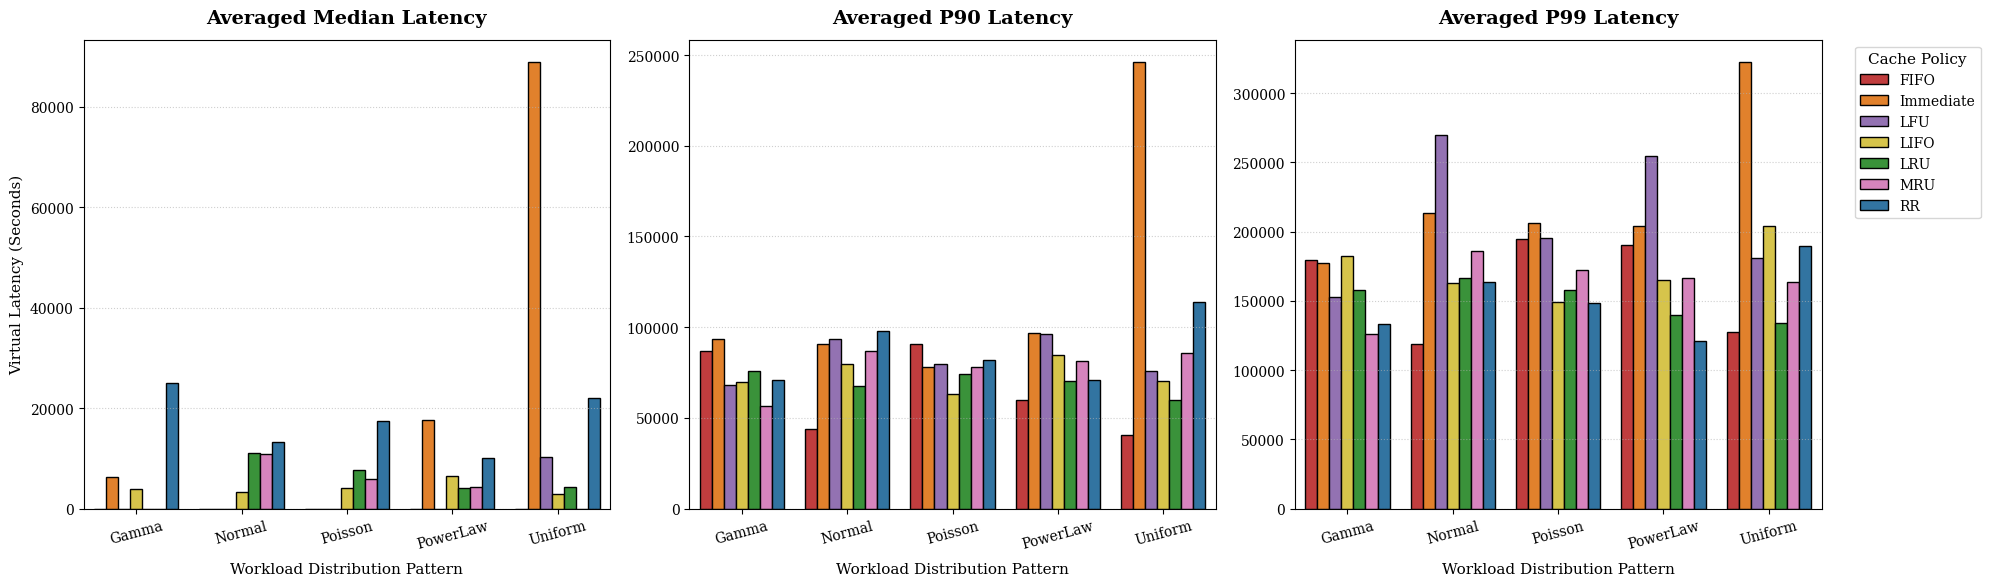

In [16]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Reuse your exact color scheme for report consistency
POLICY_COLORS = {
    'LRU': '#2ca02c',
    'RR': '#1f77b4',
    'Immediate': '#ff7f0e',
    'LFU': '#9467bd',
    'FIFO': '#d62728',
    'LIFO': '#edd534',
    'MRU': '#e377c2',
    'LFRU': '#7f7f7f'
}

def load_and_average_results(pattern="../res/real_life/bench_*.csv"):
    single_model_runs = []
    files = glob.glob(pattern)
    
    for f in files:
        base = os.path.basename(f).replace('.csv', '')
        parts = base.split('_')
        if len(parts) < 6 or parts[0] != 'bench' or parts[3] != 'Multi':
            continue
            
        policy, dist_type = parts[1], parts[2]
        num_clients = int(parts[4].replace('c', ''))
        iteration = int(parts[5].replace('iter', ''))

        df = pd.read_csv(f)
        req_df = df.groupby('RequestID')['Duration_Sec'].sum().reset_index()
        req_df['Policy'] = policy
        req_df['Distribution'] = dist_type
        req_df['Clients'] = num_clients
        req_df['Iteration'] = iteration
        single_model_runs.append(req_df)

    if not single_model_runs:
        print("No matching single-model data files found.")
        return pd.DataFrame()

    combined_df = pd.concat(single_model_runs, ignore_index=True)
    
    # Calculate quantiles per iteration
    iter_quantiles = combined_df.groupby(['Policy', 'Distribution', 'Clients', 'Iteration'])['Duration_Sec'].agg(
        Median='median',
        P90=lambda x: x.quantile(0.90),
        P99=lambda x: x.quantile(0.99)
    ).reset_index()
    
    # Average quantiles across all 10 iterations
    averaged_df = iter_quantiles.groupby(['Policy', 'Distribution', 'Clients'])[['Median', 'P90', 'P99']].mean().reset_index()
    averaged_df.columns = ['Policy', 'Distribution', 'Clients', 'Median Latency', 'P90 Latency', 'P99 Latency']
    return averaged_df

def plot_combined_metrics(df_avg):
    if df_avg.empty:
        return
        
    # Transform data from wide to long format for clean seaborn faceting
    df_melted = pd.melt(
        df_avg, 
        id_vars=['Policy', 'Distribution', 'Clients'], 
        value_vars=['Median Latency', 'P90 Latency', 'P99 Latency'],
        var_name='Metric', 
        value_name='Latency_Sec'
    )

    # Setup a 1-row, 3-column subplots figure structure to prevent overlapping text
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
    metrics = ['Median Latency', 'P90 Latency', 'P99 Latency']
    
    # Define a clean alphabetical sorting for the policies to lock bar order
    policy_order = sorted(df_avg['Policy'].unique())

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        metric_data = df_melted[df_melted['Metric'] == metric]
        
        sns.barplot(
            data=metric_data, 
            x='Distribution', 
            y='Latency_Sec', 
            hue='Policy', 
            hue_order=policy_order,
            palette=POLICY_COLORS, 
            edgecolor='black',
            linewidth=1,
            ax=ax
        )
        
        # Style configuration for clean academic aesthetics
        ax.set_title(f"Averaged {metric}", fontsize=14, fontweight='bold', pad=12)
        ax.set_xlabel("Workload Distribution Pattern", fontsize=11, labelpad=8)
        ax.set_ylabel("Virtual Latency (Seconds)" if idx == 0 else "", fontsize=11)
        ax.grid(axis='y', linestyle=':', alpha=0.6)
        ax.tick_params(axis='x', rotation=15) # Subtle tilt to prevent label truncation
        
        # Consolidate legends into a single master legend on the far right subplot
        if idx != len(metrics) - 1:
            ax.get_legend().remove()
        else:
            ax.legend(title='Cache Policy', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

    plt.tight_layout()
    
    # Save directly as a high-resolution file for your LaTeX document
    output_path = "cache_policies_comparative_summary.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Successfully generated and saved comparison matrix to: {output_path}")

# --- Execution Flow ---
df_multi_avg = load_and_average_results()
plot_combined_metrics(df_multi_avg)

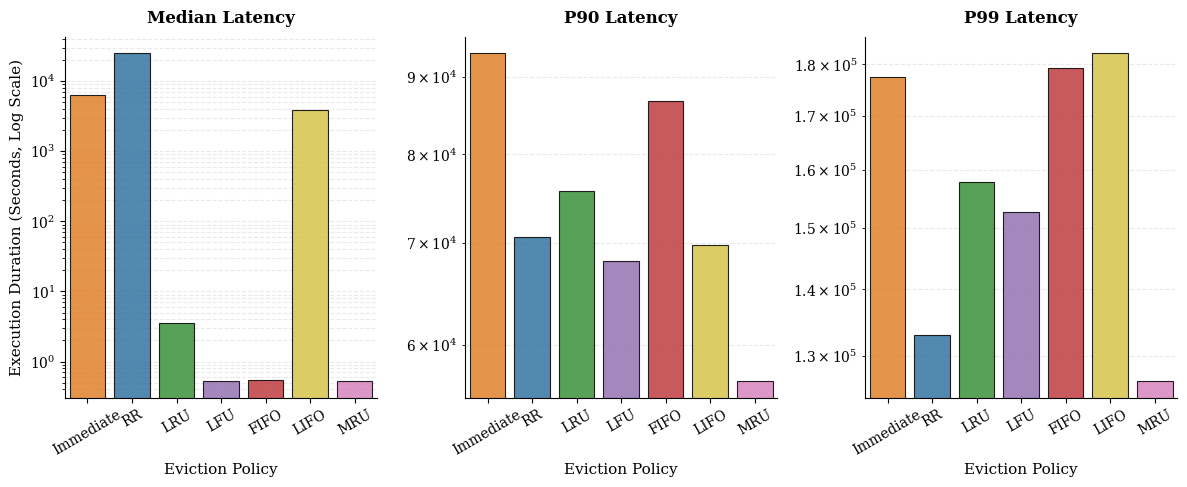

In [17]:
df_multi_avg
df = df_multi_avg[(df_multi_avg['Distribution'] == 'Gamma')]
df_melted = pd.melt(
    df, 
    id_vars=['Policy', 'Distribution'], 
    value_vars=['Median Latency', 'P90 Latency', 'P99 Latency'],
    var_name='Metric', 
    value_name='Latency_Sec'
)

# 3. Apply institutional styling defaults (ACM / IEEE Transaction style basics)
plt.rcParams.update({
    'font.family': 'serif',       # Use professional serif typeface (matches LaTeX body text)
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14
})

# Define your strict policy order to ensure consistent presentation across charts
policy_order = ["Immediate", "RR", "LRU", "LFU", "FIFO", "LIFO", "MRU"]

# Reuse your exact color mapping dictionary to maintain coherence across your thesis figures
POLICY_COLORS = {
    'LRU': '#2ca02c', 'RR': '#1f77b4', 'Immediate': '#ff7f0e', 'LFU': '#9467bd',
    'FIFO': '#d62728', 'LIFO': '#edd534', 'MRU': '#e377c2'
}

# 4. Construct the FacetGrid
# We share the x-axis, but set sharey=False so each metric can scale its axis naturally
g = sns.FacetGrid(
    df_melted, 
    col="Metric", 
    col_order=['Median Latency', 'P90 Latency', 'P99 Latency'],
    sharey=False, 
    sharex=True,
    height=5, 
    aspect=0.8
)

# 5. Map the bar plot onto the grid matrix
g.map_dataframe(
    sns.barplot, 
    x='Policy', 
    y='Latency_Sec', 
    hue='Policy',
    order=policy_order,
    hue_order=policy_order,
    palette=POLICY_COLORS,
    edgecolor='black',
    linewidth=0.8,
    alpha=0.85
)

# 6. Polishing axes, grid structures, and text labels
# 6. Polishing axes, grid structures, and text labels
for ax in g.axes.flat:
    current_title = ax.get_title().split('=')[-1].strip()
    ax.set_title(current_title, fontweight='bold', pad=10)
    
    # CRITICAL CHANGE: Switch the vertical axis to log scale
    ax.set_yscale('log')
    
    # Configure clean gridlines that look good on a log scale
    ax.grid(axis='y', which='both', linestyle='--', alpha=0.4, color='#cccccc')
    ax.set_axisbelow(True)
    
    ax.set_xlabel("Eviction Policy")
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("Execution Duration (Seconds, Log Scale)")
    else:
        ax.set_ylabel("")
        
    ax.tick_params(axis='x', rotation=30)

# Adjust spacing properties to fit tightly within standard margins
plt.tight_layout()

# Save as vector graphics (.pdf) or high-resolution raster (.png) for clean print inclusion
output_img = "gamma_distribution_metrics_comparison.pdf"
plt.savefig(output_img, bbox_inches='tight', dpi=300)
plt.show()

In [20]:
# 1. Enforce your explicit academic custom ordering
desired_policies = ["Immediate", "RR", "LRU", "LFU", "FIFO", "LIFO", "MRU"]
# desired_dists = ["Uniform", "Normal", "PowerLaw", "Poisson", "Gamma"]
desired_dists = ["Gamma", "PowerLaw", "Poisson"]  # Adjust this list based on your actual distributions in the DataFrame

# Filter out only the policies and distributions that exist in your current DataFrame slice
policies = [p for p in desired_policies if p in df_multi_avg['Policy'].unique()]
distributions = [d for d in desired_dists if d in df_multi_avg['Distribution'].unique()]

# 2. Build the LaTeX table string
latex_str = "% \\usepackage{booktabs} -- Mandatory for clean professional horizontal lines\n"
latex_str += "% \\usepackage{multirow} -- Mandatory for multirow alignment\n"
latex_str += "\\begin{table*}[htbp]\n"
latex_str += "\\centering\n"
latex_str += "\\caption{Cache Eviction Policy Performance Matrix across Workload Distributions (Seconds)}\n"
latex_str += "\\label{tab:policy_perf_matrix}\n"

# Setup column alignments: 1 left-aligned for metrics/policies, and right-aligned for each distribution
col_alignment = "ll" + "r" * len(distributions)
latex_str += f"\\begin{{tabular}}{{{col_alignment}}}\n"
latex_str += "\\toprule\n"

# Table Header Row - Now follows your exact distribution sequence
headers = ["Policy", "Metric"] + distributions
latex_str += " & ".join(headers) + " \\\\\n"
latex_str += "\\midrule\n"

# Populate the Matrix using the strict order arrays
for policy in policies:
    # Handle specific renaming for LaTeX presentation if your dataframe uses abbreviations
    display_policy = "Random (RR)" if policy == "RR" else policy
    
    med_row = f"\\multirow{{3}}{{*}}{{\\textbf{{{display_policy}}}}}" + " & Median"
    p90_row = " & P90"
    p99_row = " & P99"
    
    for dist in distributions:
        # Filter for the intersection cell matching current row/col
        subset = df_multi_avg[(df_multi_avg['Policy'] == policy) & (df_multi_avg['Distribution'] == dist)]
        
        if not subset.empty:
            row_data = subset.iloc[0]
            # Look up values dynamically based on what your dataframe columns are named
            med_col = 'Median Latency' if 'Median Latency' in row_data else 'Avg_Median_Sec'
            p90_col = 'P90 Latency' if 'P90 Latency' in row_data else 'Avg_P90_Sec'
            p99_col = 'P99 Latency' if 'P99 Latency' in row_data else 'Avg_P99_Sec'
            
            med_val = f"{row_data[med_col]:.3f}"
            p90_val = f"{row_data[p90_col]:.3f}"
            p99_val = f"{row_data[p99_col]:.3f}"
        else:
            # Fallback if a specific permutation run is missing or skipped
            med_val = p90_val = p99_val = "N/A"
            
        med_row += f" & {med_val}"
        p90_row += f" & {p90_val}"
        p99_row += f" & {p99_val}"
        
    latex_str += med_row + " \\\\\n"
    latex_str += p90_row + " \\\\\n"
    latex_str += p99_row + " \\\\\n"
    latex_str += "\\cmidrule(lr){1-1} \\cmidrule(lr){2-2} " + " ".join([f"\\cmidrule(lr){{{i+3}-{i+3}}}" for i in range(len(distributions))]) + "\n"

# Strip the trailing midrule safely and seal the table structure
latex_str = latex_str.rsplit('\\cmidrule', 1)[0] + "\\bottomrule\n\\end{tabular}\n\\end{table*}"

print(latex_str)

% \usepackage{booktabs} -- Mandatory for clean professional horizontal lines
% \usepackage{multirow} -- Mandatory for multirow alignment
\begin{table*}[htbp]
\centering
\caption{Cache Eviction Policy Performance Matrix across Workload Distributions (Seconds)}
\label{tab:policy_perf_matrix}
\begin{tabular}{llrrr}
\toprule
Policy & Metric & Gamma & PowerLaw & Poisson \\
\midrule
\multirow{3}{*}{\textbf{Immediate}} & Median & 6324.139 & 17576.689 & 0.521 \\
 & P90 & 93225.288 & 97010.697 & 78292.655 \\
 & P99 & 177436.614 & 204120.381 & 206252.066 \\
\cmidrule(lr){1-1} \cmidrule(lr){2-2} \cmidrule(lr){3-3} \cmidrule(lr){4-4} \cmidrule(lr){5-5}
\multirow{3}{*}{\textbf{Random (RR)}} & Median & 25024.318 & 10165.857 & 17388.210 \\
 & P90 & 70643.997 & 70970.390 & 81664.392 \\
 & P99 & 133032.145 & 121130.938 & 148190.850 \\
\cmidrule(lr){1-1} \cmidrule(lr){2-2} \cmidrule(lr){3-3} \cmidrule(lr){4-4} \cmidrule(lr){5-5}
\multirow{3}{*}{\textbf{LRU}} & Median & 3.573 & 4122.507 & 7788.317 \\
 & 

Successfully generated and saved comparison matrix to: cache_policies_comparative_summary.pdf


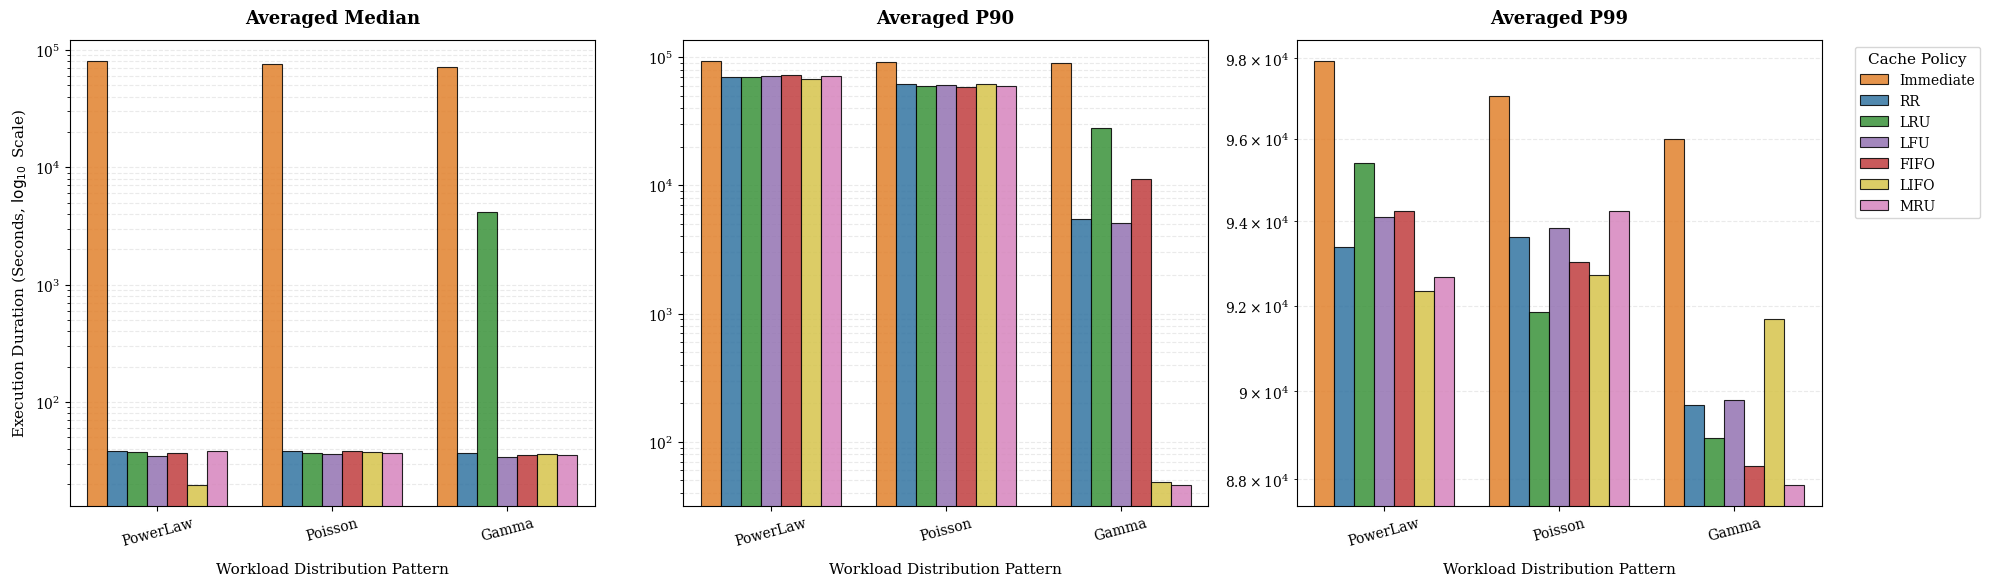

In [21]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Institutional styling defaults (Academic/Thesis Publication Style)
plt.rcParams.update({
    'font.family': 'serif',       # Use professional serif typeface matching LaTeX
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14
})

# Reuse your exact color scheme for report consistency
POLICY_COLORS = {
    'LRU': '#2ca02c', 'RR': '#1f77b4', 'Immediate': '#ff7f0e', 'LFU': '#9467bd',
    'FIFO': '#d62728', 'LIFO': '#edd534', 'MRU': '#e377c2', 'LFRU': '#7f7f7f'
}

def load_and_average_results(pattern="../res/real_life/bench_*.csv"):
    single_model_runs = []
    files = glob.glob(pattern)
    
    for f in files:
        base = os.path.basename(f).replace('.csv', '')
        parts = base.split('_')
        if len(parts) < 6 or parts[0] != 'bench' or parts[3] != 'Single':
            continue
            
        policy, dist_type = parts[1], parts[2]
        
        # Explicit Filter: Only consider Gamma, PowerLaw, and Poisson
        if dist_type not in ["Gamma", "PowerLaw", "Poisson"]:
            continue
            
        num_clients = int(parts[4].replace('c', ''))
        iteration = int(parts[5].replace('iter', ''))

        df = pd.read_csv(f)
        req_df = df.groupby('RequestID')['Duration_Sec'].sum().reset_index()
        req_df['Policy'] = policy
        req_df['Distribution'] = dist_type
        req_df['Clients'] = num_clients
        req_df['Iteration'] = iteration
        single_model_runs.append(req_df)

    if not single_model_runs:
        print("No matching single-model data files found for the selected distributions.")
        return pd.DataFrame()

    combined_df = pd.concat(single_model_runs, ignore_index=True)
    
    # Calculate quantiles per iteration
    iter_quantiles = combined_df.groupby(['Policy', 'Distribution', 'Clients', 'Iteration'])['Duration_Sec'].agg(
        Median='median',
        P90=lambda x: x.quantile(0.90),
        P99=lambda x: x.quantile(0.99)
    ).reset_index()
    
    # Average quantiles across all 10 iterations
    averaged_df = iter_quantiles.groupby(['Policy', 'Distribution', 'Clients'])[['Median', 'P90', 'P99']].mean().reset_index()
    averaged_df.columns = ['Policy', 'Distribution', 'Clients', 'Median Latency', 'P90 Latency', 'P99 Latency']
    return averaged_df

def plot_combined_metrics(df_avg):
    if df_avg.empty:
        return
        
    # Transform data from wide to long format for clean seaborn faceting
    df_melted = pd.melt(
        df_avg, 
        id_vars=['Policy', 'Distribution', 'Clients'], 
        value_vars=['Median Latency', 'P90 Latency', 'P99 Latency'],
        var_name='Metric', 
        value_name='Latency_Sec'
    )

    # Setup a 1-row, 3-column subplots figure structure
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
    metrics = ['Median Latency', 'P90 Latency', 'P99 Latency']
    
    # Enforce your explicit academic custom ordering
    policy_order = ["Immediate", "RR", "LRU", "LFU", "FIFO", "LIFO", "MRU"]
    distribution_order = ["PowerLaw", "Poisson", "Gamma"]

    # Intersect with what actually exists in your dataframe slice to avoid KeyError
    valid_policies = [p for p in policy_order if p in df_avg['Policy'].unique()]
    valid_dists = [d for d in distribution_order if d in df_avg['Distribution'].unique()]

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        metric_data = df_melted[df_melted['Metric'] == metric]
        
        sns.barplot(
            data=metric_data, 
            x='Distribution', 
            y='Latency_Sec', 
            hue='Policy', 
            order=valid_dists,
            hue_order=valid_policies,
            palette=POLICY_COLORS, 
            edgecolor='black',
            linewidth=0.8,
            alpha=0.85,
            ax=ax
        )
        
        # Apply Logarithmic Scale to keep smaller variations visible alongside massive values
        ax.set_yscale('log')
        
        # Style configuration for clean academic aesthetics
        ax.set_title(f"Averaged {metric.split()[0]}", fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel("Workload Distribution Pattern", fontsize=11, labelpad=10)
        ax.set_ylabel("Execution Duration (Seconds, $\log_{10}$ Scale)" if idx == 0 else "", fontsize=11)
        
        # Configure clean gridlines that align correctly with log scale divisions
        ax.grid(axis='y', which='both', linestyle='--', alpha=0.4, color='#cccccc')
        ax.set_axisbelow(True)
        ax.tick_params(axis='x', rotation=15)
        
        # Consolidate legends into a single master legend on the far right subplot
        if idx != len(metrics) - 1:
            ax.get_legend().remove()
        else:
            ax.legend(title='Cache Policy', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

    plt.tight_layout()
    
    # Save as high-resolution vector format (.pdf) for clean rendering inside LaTeX document columns
    output_path = "cache_policies_comparative_summary.pdf"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Successfully generated and saved comparison matrix to: {output_path}")

# --- Execution Flow ---
df_single_avg = load_and_average_results()
plot_combined_metrics(df_single_avg)

/var/folders/k0/q2ncgz050jd3c9d6y1qks52c0000gn/T/ipykernel_34319/3836545616.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(single_model_runs, ignore_index=True)


Successfully generated and saved comparison matrix to: cache_policies_comparative_summary.pdf


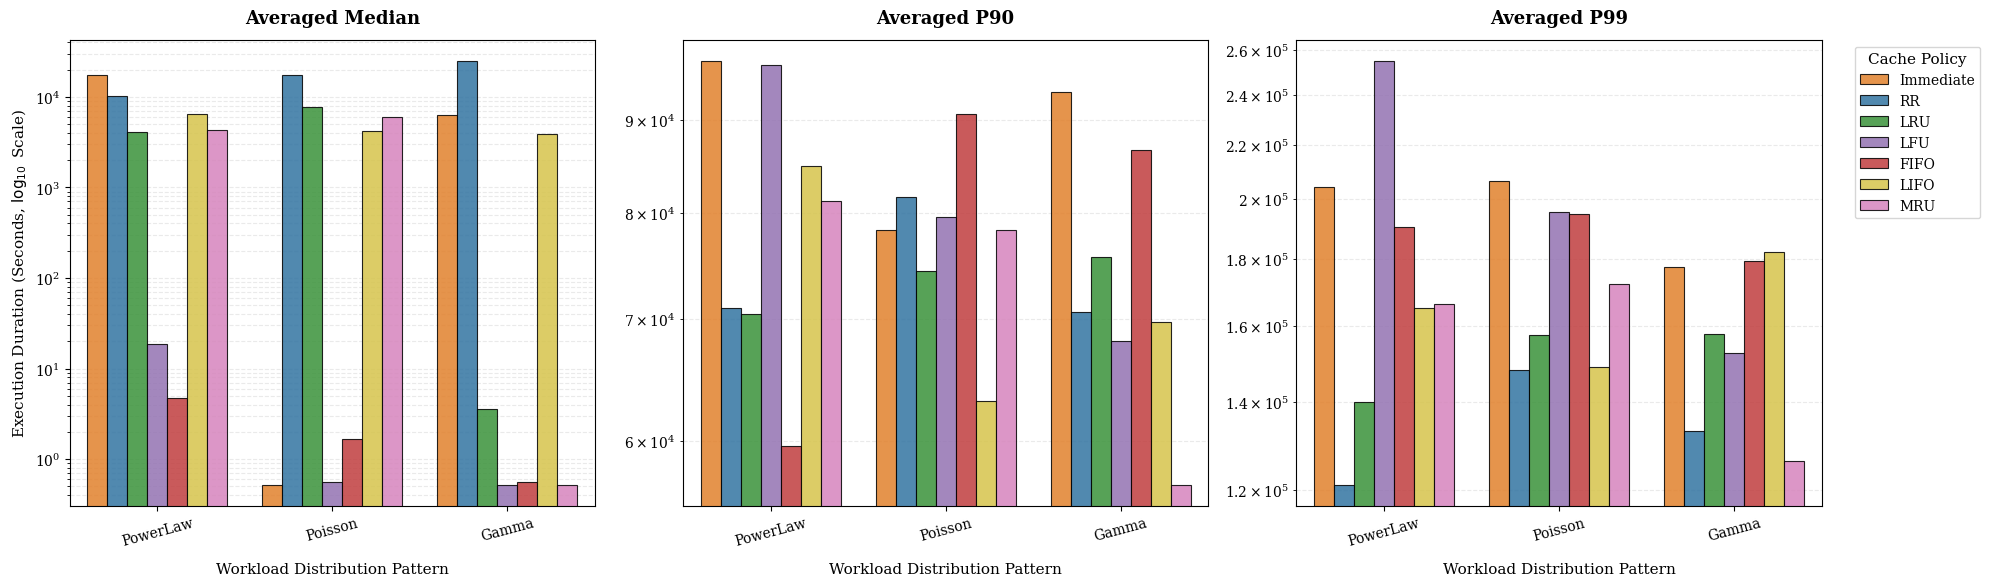

In [22]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Institutional styling defaults (Academic/Thesis Publication Style)
plt.rcParams.update({
    'font.family': 'serif',       # Use professional serif typeface matching LaTeX
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14
})

# Reuse your exact color scheme for report consistency
POLICY_COLORS = {
    'LRU': '#2ca02c', 'RR': '#1f77b4', 'Immediate': '#ff7f0e', 'LFU': '#9467bd',
    'FIFO': '#d62728', 'LIFO': '#edd534', 'MRU': '#e377c2', 'LFRU': '#7f7f7f'
}

def load_and_average_results(pattern="../res/real_life/bench_*.csv"):
    single_model_runs = []
    files = glob.glob(pattern)
    
    for f in files:
        base = os.path.basename(f).replace('.csv', '')
        parts = base.split('_')
        if len(parts) < 6 or parts[0] != 'bench' or parts[3] != 'Multi':
            continue
            
        policy, dist_type = parts[1], parts[2]
        
        # Explicit Filter: Only consider Gamma, PowerLaw, and Poisson
        if dist_type not in ["Gamma", "PowerLaw", "Poisson"]:
            continue
            
        num_clients = int(parts[4].replace('c', ''))
        iteration = int(parts[5].replace('iter', ''))

        df = pd.read_csv(f)
        req_df = df.groupby('RequestID')['Duration_Sec'].sum().reset_index()
        req_df['Policy'] = policy
        req_df['Distribution'] = dist_type
        req_df['Clients'] = num_clients
        req_df['Iteration'] = iteration
        single_model_runs.append(req_df)

    if not single_model_runs:
        print("No matching single-model data files found for the selected distributions.")
        return pd.DataFrame()

    combined_df = pd.concat(single_model_runs, ignore_index=True)
    
    # Calculate quantiles per iteration
    iter_quantiles = combined_df.groupby(['Policy', 'Distribution', 'Clients', 'Iteration'])['Duration_Sec'].agg(
        Median='median',
        P90=lambda x: x.quantile(0.90),
        P99=lambda x: x.quantile(0.99)
    ).reset_index()
    
    # Average quantiles across all 10 iterations
    averaged_df = iter_quantiles.groupby(['Policy', 'Distribution', 'Clients'])[['Median', 'P90', 'P99']].mean().reset_index()
    averaged_df.columns = ['Policy', 'Distribution', 'Clients', 'Median Latency', 'P90 Latency', 'P99 Latency']
    return averaged_df

def plot_combined_metrics(df_avg):
    if df_avg.empty:
        return
        
    # Transform data from wide to long format for clean seaborn faceting
    df_melted = pd.melt(
        df_avg, 
        id_vars=['Policy', 'Distribution', 'Clients'], 
        value_vars=['Median Latency', 'P90 Latency', 'P99 Latency'],
        var_name='Metric', 
        value_name='Latency_Sec'
    )

    # Setup a 1-row, 3-column subplots figure structure
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
    metrics = ['Median Latency', 'P90 Latency', 'P99 Latency']
    
    # Enforce your explicit academic custom ordering
    policy_order = ["Immediate", "RR", "LRU", "LFU", "FIFO", "LIFO", "MRU"]
    distribution_order = ["PowerLaw", "Poisson", "Gamma"]

    # Intersect with what actually exists in your dataframe slice to avoid KeyError
    valid_policies = [p for p in policy_order if p in df_avg['Policy'].unique()]
    valid_dists = [d for d in distribution_order if d in df_avg['Distribution'].unique()]

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        metric_data = df_melted[df_melted['Metric'] == metric]
        
        sns.barplot(
            data=metric_data, 
            x='Distribution', 
            y='Latency_Sec', 
            hue='Policy', 
            order=valid_dists,
            hue_order=valid_policies,
            palette=POLICY_COLORS, 
            edgecolor='black',
            linewidth=0.8,
            alpha=0.85,
            ax=ax
        )
        
        # Apply Logarithmic Scale to keep smaller variations visible alongside massive values
        ax.set_yscale('log')
        
        # Style configuration for clean academic aesthetics
        ax.set_title(f"Averaged {metric.split()[0]}", fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel("Workload Distribution Pattern", fontsize=11, labelpad=10)
        ax.set_ylabel("Execution Duration (Seconds, $\log_{10}$ Scale)" if idx == 0 else "", fontsize=11)
        
        # Configure clean gridlines that align correctly with log scale divisions
        ax.grid(axis='y', which='both', linestyle='--', alpha=0.4, color='#cccccc')
        ax.set_axisbelow(True)
        ax.tick_params(axis='x', rotation=15)
        
        # Consolidate legends into a single master legend on the far right subplot
        if idx != len(metrics) - 1:
            ax.get_legend().remove()
        else:
            ax.legend(title='Cache Policy', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

    plt.tight_layout()
    
    # Save as high-resolution vector format (.pdf) for clean rendering inside LaTeX document columns
    output_path = "cache_policies_comparative_summary.pdf"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Successfully generated and saved comparison matrix to: {output_path}")

# --- Execution Flow ---
df_single_avg = load_and_average_results()
plot_combined_metrics(df_single_avg)